# Primer Parcial- Parte 1: Preprocesamiento de Datos y Análisis Estadístico Exploratorio
# Ruben Dario Lopez Sanabria CI:4328194
### Machine Learning 1 (23433)
#### Facultad de Ingeniería - Universidad Nacional de Asunción (FIUNA)

---

## Objetivos de la Parte 1
1. Cargar e inspeccionar la estructura del conjunto de datos unificado de rendimiento académico de FIUNA (`reglamento_nuevo_unificado.csv`).
2. Mapear las 27 siglas e intensificaciones curriculares a las 7 carreras principales de la facultad.
3. Aplicar un preprocesamiento de integridad de datos **no destructivo** que preserve el 100% de los 64,295 registros sin eliminar filas.
4. Responder a 6 preguntas estadísticas exploratorias clave para auditar la masa estudiantil, la retención académica y las tasas de aprobación.


In [1]:
# 1. Carga de Librerías Fundamentales
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_columns', 25)
pd.set_option('display.width', 1000)

# Carga del Dataset
csv_path = 'reglamento_nuevo_unificado.csv'
if not os.path.exists(csv_path):
    csv_path = os.path.join('..', 'Clase_5', 'reglamento_nuevo_unificado.csv')

df_raw = pd.read_csv(csv_path)
print(f"Dataset cargado exitosamente: {df_raw.shape[0]:,} filas y {df_raw.shape[1]} columnas.")


Dataset cargado exitosamente: 64,295 filas y 29 columnas.


## Mapeo de Intensificaciones Curriculares a Carreras Principales

Completa el diccionario `career_code_mapping` para mapear las 27 siglas del sistema (`CIV-PLS13`, `INT9CONSTR`, `ELE-PLS23`, `INT9SDIGYT`, `MCT-PLS13`, `IND-PLS13`, `CGF-PLS13`, `MEC-PLS13`, `ECA-PLS13`, etc.) a sus 7 carreras principales:
- `Ing. Civil`
- `Ing. Electrónica`
- `Ing. Mecatrónica`
- `Ing. Industrial`
- `Ing. Geográfica`
- `Ing. Mecánica`
- `Ing. Electromecánica`


In [2]:

career_code_mapping = {
   
    'CIV-PLS13': 'Ing. Civil', 'CIV-PLS23': 'Ing. Civil', 'INT9CONSTR': 'Ing. Civil',
    'INT9TRANSP': 'Ing. Civil', 'INT9ORTERR': 'Ing. Civil', 'INT9SANEHI': 'Ing. Civil',
    
    'ELE-PLS13': 'Ing. Electromecánica', 'ELE-PLS23': 'Ing. Electromecánica',
    'INT9ELECTR': 'Ing. Electromecánica', 'INT9SDIGYT': 'Ing. Electromecánica',
    
    'MCT-PLS13': 'Ing. Mecatrónica', 'MCT-PLS23': 'Ing. Mecatrónica', 'MCT9-OPT': 'Ing. Mecatrónica',
    
    'IND-PLS13': 'Ing. Industrial', 'IND-PLS23': 'Ing. Industrial',
    'INT9G-ECO': 'Ing. Industrial', 'INT9-PROYT': 'Ing. Industrial',
    
    'CGF-PLS13': 'Ing. Geográfica', 'CGF-PLS23': 'Ing. Geográfica', 'INT9RNYMA': 'Ing. Geográfica',
    
    'MEC-PLS13': 'Ing. Mecánica', 'MEC-PLS23': 'Ing. Mecánica',
    'INT9MECANI': 'Ing. Mecánica', 'MEC9-OPT': 'Ing. Mecánica',
    
    'ECA-PLS13': 'Ing. Electrónica', 'ECA-PLS23': 'Ing. Electrónica', 'ECA9-OPT': 'Ing. Electrónica'
}

df_clean = df_raw.copy()
# TODO: Asignar la nueva columna Carrera_Nombre usando map()
df_clean['Carrera_Nombre'] = df_clean['Cod.Car.Sec'].astype(str).str.strip().map(career_code_mapping)

# Definición del Target Binario (1 para 'S', 0 para 'N')
df_clean = df_clean.dropna(subset=['Aprobado', 'Carrera_Nombre']).copy()
df_clean['Target'] = (df_clean['Aprobado'] == 'S').astype(int)

print(f"Filas tras mapeo de carreras: {len(df_clean):,}")


Filas tras mapeo de carreras: 64,295


## Limpieza Numérica y Generación de Atributos Derivados (Sin Eliminación de Filas)

Convierte los campos numéricos de parciales y evaluaciones a formato float utilizando `pd.to_numeric(..., errors='coerce')` para mantener el 100% de las filas.
Crea las siguientes variables derivadas:
- `Score_Parciales`: Promedio entre el 1er y 2do parcial.
- `Diff_Parciales`: Diferencia ($2^\circ\text{Par} - 1^\circ\text{Par}$).


In [3]:
# TODO: Limpiar y convertir atributos numéricos sin eliminar filas
# === ESCRIBE TU CÓDIGO AQUÍ ===
df_clean['Primer_Par_Clean'] = pd.to_numeric(df_clean['Primer.Par'], errors='coerce')
df_clean['Segundo_Par_Clean'] = pd.to_numeric(df_clean['Segundo.Par'], errors='coerce')
df_clean['Score_Parciales'] = (df_clean['Primer_Par_Clean'].fillna(0) + df_clean['Segundo_Par_Clean'].fillna(0)) / 2.0
df_clean['Diff_Parciales'] = df_clean['Segundo_Par_Clean'].fillna(0) - df_clean['Primer_Par_Clean'].fillna(0)
df_clean['TPLab_Clean'] = pd.to_numeric(df_clean['TPLab.'], errors='coerce')
df_clean['Asis_Clean'] = pd.to_numeric(df_clean['Asis'], errors='coerce')
df_clean['Firma_Clean'] = pd.to_numeric(df_clean['Firma'], errors='coerce')
df_clean['FirmaCalc_Clean'] = pd.to_numeric(df_clean['FirmaCalculada'], errors='coerce')

print(f"Filas preservadas en df_clean: {len(df_clean):,} (100% retención)")
#Guardar dataset Limpio para usar en la parte 2
df_clean.to_csv('reglamento_dfclean.csv', index=False)
print("Dataset se guardo con exito")


Filas preservadas en df_clean: 64,295 (100% retención)
Dataset se guardo con exito


## Preguntas para el parcial: Remonta no remonta
1. Elegir una materia y analizar entre carreras la cantidad de alumnos que pasan la materia despues de haber tenido un mal primer parcial
2. Analizar de estos alumnos que tal les fue en el semestre anterior 
3. Ver cuantas materias estan llevando estos alumnos y que relacion tiene esto con su rendimiento en la materia elegida


In [4]:
import pandas as pd

# 1. Cargar el dataset limpio
df_clean = pd.read_csv('reglamento_dfclean.csv')

# 2. Identificar los conjuntos de alumnos por asignatura
# Asignatura exacta solicitada: 'PROBABILIDAD'
alumnos_probabilidad = set(df_clean[df_clean['Asignatura'] == 'PROBABILIDAD']['ALUMNO_ID'].unique())

# Asignatura alternativa: 'PROBABILIDAD Y ESTADISTICA'
alumnos_prob_y_est = set(df_clean[df_clean['Asignatura'] == 'PROBABILIDAD Y ESTADISTICA']['ALUMNO_ID'].unique())

# 3. Detectar si existen alumnos matriculados en ambas materias
alumnos_en_ambas = alumnos_probabilidad.intersection(alumnos_prob_y_est)

print(f"Total de alumnos matriculados en PROBABILIDAD: {len(alumnos_probabilidad):,}")
print(f"Total de alumnos matriculados en PROBABILIDAD Y ESTADISTICA: {len(alumnos_prob_y_est):,}")
print(f"Alumnos matriculados en ambas materias simultáneamente: {len(alumnos_en_ambas):,}")

# 4. Filtrar el DataFrame principal exclusivamente para el grupo objetivo de Probabilidad
df_probabilidad_grupo = df_clean[df_clean['Asignatura'] == 'PROBABILIDAD'].copy()

# Opcional: Si deseas etiquetar o separar a los que también cursaron la otra materia para el análisis posterior:
df_probabilidad_grupo['Cursa_Ambas'] = df_probabilidad_grupo['ALUMNO_ID'].isin(alumnos_en_ambas)

print(f"Dimensiones del dataset filtrado para el grupo de Probabilidad: {df_probabilidad_grupo.shape}")

Total de alumnos matriculados en PROBABILIDAD: 1,080
Total de alumnos matriculados en PROBABILIDAD Y ESTADISTICA: 10
Alumnos matriculados en ambas materias simultáneamente: 6
Dimensiones del dataset filtrado para el grupo de Probabilidad: (1457, 40)


## Preguntas para el parcial: Remonta no remonta
1. Elegir una materia y analizar entre carreras la cantidad de alumnos que pasan la materia despues de haber tenido un mal primer parcial



In [5]:
import pandas as pd

# 1. Cargar el dataset limpio
df_clean = pd.read_csv('reglamento_dfclean.csv')

# 2. Filtrar estrictamente para la materia 'PROBABILIDAD'
df_prob = df_clean[df_clean['Asignatura'] == 'PROBABILIDAD'].copy()

# 3. Filtrar aquellos alumnos con un "mal primer parcial" (< 50)
mal_primer_parcial = df_prob[df_prob['Primer_Par_Clean'] < 50].copy()

# 4. Agrupar por carrera para analizar la cantidad total con mal parcial, cuántos pasaron y su tasa de éxito
analisis_carreras = mal_primer_parcial.groupby('Carrera_Nombre').agg(
    Total_Mal_Parcial=('ALUMNO_ID', 'nunique'),
    Pasan_Materia=('Target', lambda x: (x == 1).sum()),
    Tasa_Exito_Porcentaje=('Target', lambda x: (x == 1).mean() * 100)
).reset_index()

# Ordenar de mayor a menor según los alumnos que lograron remontar
analisis_carreras = analisis_carreras.sort_values(by='Pasan_Materia', ascending=False)

print("--- Análisis de Alumnos que Remontan con Mal Primer Parcial en Probabilidad ---")
print(analisis_carreras.to_string(index=False))

--- Análisis de Alumnos que Remontan con Mal Primer Parcial en Probabilidad ---
      Carrera_Nombre  Total_Mal_Parcial  Pasan_Materia  Tasa_Exito_Porcentaje
          Ing. Civil                301             64              17.827298
Ing. Electromecánica                162             40              21.276596
     Ing. Geográfica                 76             12              12.500000
    Ing. Mecatrónica                 58             12              18.181818
     Ing. Industrial                 32             12              33.333333
    Ing. Electrónica                 22              4              15.384615
       Ing. Mecánica                 26              2               5.263158


In [6]:
import pandas as pd

# 1. Cargar el dataset limpio
df_clean = pd.read_csv('reglamento_dfclean.csv')

# 2. Filtrar para la materia 'PROBABILIDAD' y alumnos con mal primer parcial (< 50)
df_prob = df_clean[df_clean['Asignatura'] == 'PROBABILIDAD'].copy()
mal_par_df = df_prob[df_prob['Primer_Par_Clean'] < 50].copy()

# 3. Obtener el historial académico de estos alumnos en el dataset (materias cursadas previamente o en general)
mal_par_students_ids = mal_par_df['ALUMNO_ID'].unique()
hist_df = df_clean[df_clean['ALUMNO_ID'].isin(mal_par_students_ids)]

# Calcular métricas históricas por alumno (excluyendo o incluyendo su trayectoria)
summary_hist = hist_df.groupby('ALUMNO_ID').agg(
    Total_Materias_Historico=('Cod.Asign', 'count'),
    Materias_Aprobadas_Historico=('Target', 'sum'),
    Tasa_Aprobacion_Historica=('Target', 'mean')
).reset_index()

# 4. Unir el historial con el rendimiento en Probabilidad
analisis_semestre_previo = mal_par_df.merge(summary_hist, on='ALUMNO_ID', how='left')

# 5. Comparar el promedio del historial académico agrupado por si aprobaron o no Probabilidad
comparativa_rendimiento = analisis_semestre_previo.groupby('Target').agg(
    Cantidad_Alumnos=('ALUMNO_ID', 'nunique'),
    Media_Materias_Cursadas_Hist=('Total_Materias_Historico', 'mean'),
    Media_Materias_Aprobadas_Hist=('Materias_Aprobadas_Historico', 'mean'),
    Tasa_Exito_Historica_Promedio=('Tasa_Aprobacion_Historica', lambda x: x.mean() * 100)
).reset_index()

# Mapear las etiquetas del target para mayor claridad
comparativa_rendimiento['Resultado_Probabilidad'] = comparativa_rendimiento['Target'].map({
    0: 'No remontaron (Reprobaron)', 
    1: 'Sí remontaron (Aprobaron)'
})

print("--- Análisis del Historial Académico Previo de los Alumnos con Mal Primer Parcial ---")
print(comparativa_rendimiento[['Resultado_Probabilidad', 'Cantidad_Alumnos', 'Media_Materias_Cursadas_Hist', 'Media_Materias_Aprobadas_Hist', 'Tasa_Exito_Historica_Promedio']].to_string(index=False))

--- Análisis del Historial Académico Previo de los Alumnos con Mal Primer Parcial ---
    Resultado_Probabilidad  Cantidad_Alumnos  Media_Materias_Cursadas_Hist  Media_Materias_Aprobadas_Hist  Tasa_Exito_Historica_Promedio
No remontaron (Reprobaron)               556                     12.561086                       4.049774                      28.041223
 Sí remontaron (Aprobaron)               146                     15.273973                       8.493151                      54.852349


In [7]:
import pandas as pd

# 1. Cargar el dataset limpio
df_clean = pd.read_csv('reglamento_dfclean.csv')

# 2. Filtrar para Probabilidad y alumnos con mal primer parcial (< 50)
df_prob = df_clean[df_clean['Asignatura'] == 'PROBABILIDAD'].copy()
mal_par_df = df_prob[df_prob['Primer_Par_Clean'] < 50].copy()
mal_par_students_ids = mal_par_df['ALUMNO_ID'].unique()

# 3. Filtrar el dataset completo para obtener el historial de estos alumnos
hist_df = df_clean[df_clean['ALUMNO_ID'].isin(mal_par_students_ids)].copy()

# 4. Filtrar las materias que aprobaron (Target == 1), excluyendo la propia materia de Probabilidad
aprobadas_previas = hist_df[(hist_df['Target'] == 1) & (hist_df['Asignatura'] != 'PROBABILIDAD')].copy()

# 5. Agrupar por alumno para listar las materias aprobadas
materias_por_alumno = aprobadas_previas.groupby('ALUMNO_ID')['Asignatura'].apply(list).reset_index()
materias_por_alumno.rename(columns={'Asignatura': 'Materias_Aprobadas_Previas'}, inplace=True)

# Unir con el resultado en Probabilidad para ver si remontaron o no
resultado_final = mal_par_df[['ALUMNO_ID', 'Carrera_Nombre', 'Primer_Par_Clean', 'Target']].drop_duplicates()
resultado_final = resultado_final.merge(materias_por_alumno, on='ALUMNO_ID', how='left')

# Rellenar con lista vacía los que no tienen materias aprobadas previas registradas
resultado_final['Materias_Aprobadas_Previas'] = resultado_final['Materias_Aprobadas_Previas'].fillna(value=lambda x: [])

# Mostrar los primeros resultados
print("--- Muestra de Materias Aprobadas Previamente por Alumno ---")
for idx, row in resultado_final.head(10).iterrows():
    estado = "Sí remontó" if row['Target'] == 1 else "No remontó"
    print(f"Alumno: {row['ALUMNO_ID']} | Carrera: {row['Carrera_Nombre']} | 1er Parcial: {row['Primer_Par_Clean']} | Estado: {estado}")
    print(f"   -> Materias previas aprobadas: {row['Materias_Aprobadas_Previas']}")
    print("-" * 80)

--- Muestra de Materias Aprobadas Previamente por Alumno ---
Alumno: FIUNA_ALUMNO_000452 | Carrera: Ing. Civil | 1er Parcial: 18 | Estado: No remontó
   -> Materias previas aprobadas: <function <lambda> at 0x00000257AAF25940>
--------------------------------------------------------------------------------
Alumno: FIUNA_ALUMNO_012722 | Carrera: Ing. Civil | 1er Parcial: 18 | Estado: No remontó
   -> Materias previas aprobadas: <function <lambda> at 0x00000257AAF25940>
--------------------------------------------------------------------------------
Alumno: FIUNA_ALUMNO_001499 | Carrera: Ing. Electromecánica | 1er Parcial: 24 | Estado: No remontó
   -> Materias previas aprobadas: ['MAQUINAS TERMICAS  1', 'ELEMENTOS DE MAQUINAS', 'INTRODUCCION A LA ENERGIA FOTOVOLTAICA']
--------------------------------------------------------------------------------
Alumno: FIUNA_ALUMNO_002386 | Carrera: Ing. Electromecánica | 1er Parcial: 24 | Estado: No remontó
   -> Materias previas aprobadas: ['MAQUIN

In [8]:
import pandas as pd

# 1. Cargar el dataset limpio
df_clean = pd.read_csv('reglamento_dfclean.csv')

# 2. Filtrar para la materia 'PROBABILIDAD' y alumnos con mal primer parcial (< 50)
df_prob = df_clean[df_clean['Asignatura'] == 'PROBABILIDAD'].copy()
mal_par_df = df_prob[df_prob['Primer_Par_Clean'] < 50].copy()

# 3. Calcular la cantidad de materias simultáneas que lleva cada alumno en su respectivo Año y Semestre
concurrencia_list = []
for idx, row in mal_par_df.iterrows():
    alumno = row['ALUMNO_ID']
    anho = row['Anho']
    sem = row['Semestre']
    target = row['Target']
    
    # Contar asignaturas únicas cursadas en ese mismo periodo lectivo
    total_materias_semestre = df_clean[
        (df_clean['ALUMNO_ID'] == alumno) & 
        (df_clean['Anho'] == anho) & 
        (df_clean['Semestre'] == sem)
    ]['Cod.Asign'].nunique()
    
    concurrencia_list.append({
        'ALUMNO_ID': alumno,
        'Target': target,
        'Materias_Simultaneas': total_materias_semestre
    })

df_concurrencia = pd.DataFrame(concurrencia_list)

# 4. Agrupar por la cantidad de materias simultáneas para ver la tasa de éxito (remontada)
analisis_carga = df_concurrencia.groupby('Materias_Simultaneas').agg(
    Total_Alumnos=('ALUMNO_ID', 'count'),
    Aprobaron_Probabilidad=('Target', 'sum'),
    Tasa_Exito_Porcentaje=('Target', lambda x: (x.mean() * 100))
).reset_index()

print("--- Relación entre Materias Simultáneas y el Éxito tras Mal Primer Parcial ---")
print(analisis_carga.to_string(index=False))

# Promedio general de carga académica según si lograron remontar o no
promedio_carga = df_concurrencia.groupby('Target')['Materias_Simultaneas'].mean().reset_index()
promedio_carga['Resultado'] = promedio_carga['Target'].map({0: 'No remontaron', 1: 'Sí remontaron'})
print("\n--- Promedio de Materias Simultáneas ---")
print(promedio_carga[['Resultado', 'Materias_Simultaneas']].to_string(index=False))

--- Relación entre Materias Simultáneas y el Éxito tras Mal Primer Parcial ---
 Materias_Simultaneas  Total_Alumnos  Aprobaron_Probabilidad  Tasa_Exito_Porcentaje
                    2             26                       6              23.076923
                    3            102                      10               9.803922
                    4            193                      22              11.398964
                    5            166                      32              19.277108
                    6            170                      40              23.529412
                    7             98                      20              20.408163
                    8             52                      16              30.769231
                    9              2                       0               0.000000

--- Promedio de Materias Simultáneas ---
    Resultado  Materias_Simultaneas
No remontaron              4.980392
Sí remontaron              5.465753


In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1. Cargar el dataset limpio
df_clean = pd.read_csv('reglamento_dfclean.csv')

# 2. Filtrar para Probabilidad y alumnos con mal primer parcial (< 50)
df_prob = df_clean[df_clean['Asignatura'] == 'PROBABILIDAD'].copy()
mal_par_df = df_prob[df_prob['Primer_Par_Clean'] < 50].copy()

# 3. Construir variables predictoras (Features)
# Historial académico previo por alumno
hist_df = df_clean[df_clean['ALUMNO_ID'].isin(mal_par_df['ALUMNO_ID'])].copy()
summary_hist = hist_df.groupby('ALUMNO_ID').agg(
    Tasa_Aprobacion_Historica=('Target', 'mean')
).reset_index()

# Materias simultáneas en el semestre
concurrencia_list = []
for idx, row in mal_par_df.iterrows():
    alumno = row['ALUMNO_ID']
    anho = row['Anho']
    sem = row['Semestre']
    total_mat = df_clean[
        (df_clean['ALUMNO_ID'] == alumno) & 
        (df_clean['Anho'] == anho) & 
        (df_clean['Semestre'] == sem)
    ]['Cod.Asign'].nunique()
    concurrencia_list.append({'ALUMNO_ID': alumno, 'Materias_Simultaneas': total_mat})

df_conc = pd.DataFrame(concurrencia_list)

# Unir todo al dataframe del modelo
model_df = mal_par_df.merge(summary_hist, on='ALUMNO_ID', how='left')
model_df = model_df.merge(df_conc, on='ALUMNO_ID', how='left')

# Limpieza de nulos en variables de modelado
model_df['Tasa_Aprobacion_Historica'] = model_df['Tasa_Aprobacion_Historica'].fillna(0)
model_df['Materias_Simultaneas'] = model_df['Materias_Simultaneas'].fillna(1)
model_df['Asis_Clean'] = model_df['Asis_Clean'].fillna(model_df['Asis_Clean'].median())

# 4. Definir variables independientes (X) y objetivo (y)
feature_cols = ['Primer_Par_Clean', 'Tasa_Aprobacion_Historica', 'Materias_Simultaneas', 'Asis_Clean']
X = model_df[feature_cols]
y = model_df['Target']

# 5. Particionar en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Entrenar el modelo de Regresión Logística
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

# 7. Evaluar el modelo
y_pred = clf.predict(X_test)
print(f"Exactitud (Accuracy) del modelo: {accuracy_score(y_test, y_pred):.4f}\n")
print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

# Mostrar el peso (coeficientes) de cada variable en la decisión del modelo
coeficientes = pd.DataFrame({
    'Variable': feature_cols,
    'Coeficiente': clf.coef_[0]
})
print("\n--- Coeficientes del Modelo de Regresión Logística ---")
print(coeficientes.to_string(index=False))

Exactitud (Accuracy) del modelo: 0.8493

Matriz de Confusión:
[[183   1]
 [ 32   3]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.85      0.99      0.92       184
           1       0.75      0.09      0.15        35

    accuracy                           0.85       219
   macro avg       0.80      0.54      0.54       219
weighted avg       0.83      0.85      0.80       219


--- Coeficientes del Modelo de Regresión Logística ---
                 Variable  Coeficiente
         Primer_Par_Clean     0.027053
Tasa_Aprobacion_Historica     3.500650
     Materias_Simultaneas    -0.041402
               Asis_Clean     0.249277


C:\Users\ruben\AppData\Local\Temp\ipykernel_16312\1790457172.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=career_breakdown, x='Tasa_Exito', y='Carrera_Nombre', palette='viridis')


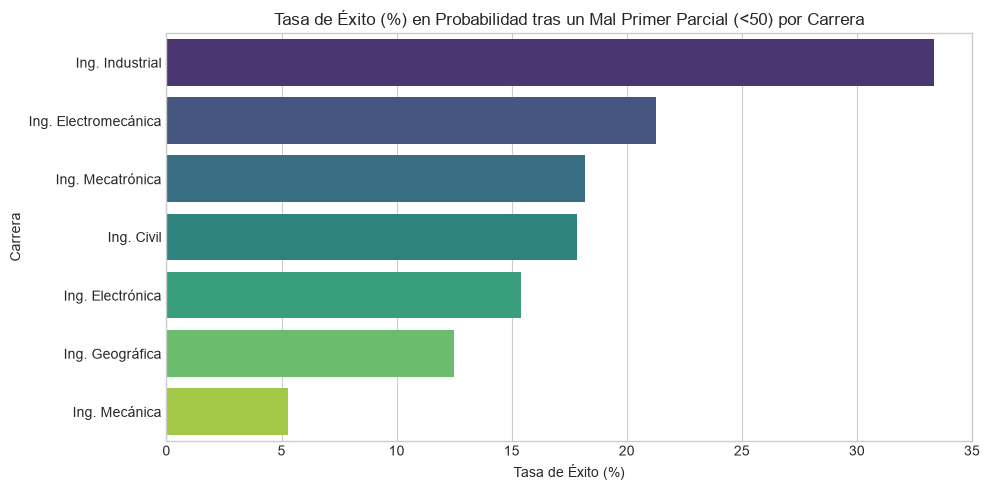

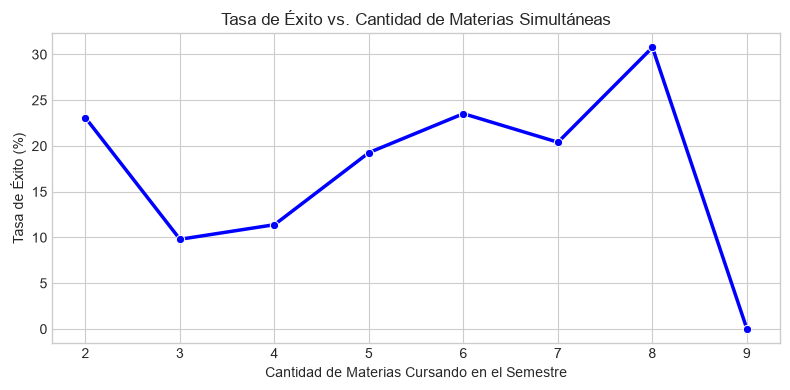

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el dataset limpio
df_clean = pd.read_csv('reglamento_dfclean.csv')

# 2. Filtrar para la materia 'Probabilidad' y alumnos con un mal primer parcial (< 50)
df_prob = df_clean[df_clean['Asignatura'] == 'PROBABILIDAD'].copy()
mal_par_df = df_prob[df_prob['Primer_Par_Clean'] < 50].copy()

# ==========================================
# GRÁFICO 1: Tasa de Éxito por Carrera
# ==========================================
career_breakdown = mal_par_df.groupby('Carrera_Nombre').agg(
    Total_Mal_Parcial=('ALUMNO_ID', 'nunique'),
    Pasan_Materia=('Target', lambda x: (x == 1).sum()),
    Tasa_Exito=('Target', lambda x: (x == 1).mean() * 100)
).reset_index().sort_values(by='Tasa_Exito', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=career_breakdown, x='Tasa_Exito', y='Carrera_Nombre', palette='viridis')
plt.title('Tasa de Éxito (%) en Probabilidad tras un Mal Primer Parcial (<50) por Carrera')
plt.xlabel('Tasa de Éxito (%)')
plt.ylabel('Carrera')
plt.tight_layout()
plt.savefig('tasa_exito_carreras.png', dpi=300)
plt.show()

# ==========================================
# GRÁFICO 2: Tasa de Éxito vs. Carga Académica (Materias Simultáneas)
# ==========================================
concurrencia_list = []
for idx, row in mal_par_df.iterrows():
    alumno = row['ALUMNO_ID']
    anho = row['Anho']
    sem = row['Semestre']
    target = row['Target']
    
    # Contar total de materias cursadas en el mismo periodo
    total_mat = df_clean[
        (df_clean['ALUMNO_ID'] == alumno) & 
        (df_clean['Anho'] == anho) & 
        (df_clean['Semestre'] == sem)
    ]['Cod.Asign'].nunique()
    
    concurrencia_list.append({
        'ALUMNO_ID': alumno, 
        'Target': target, 
        'Materias_Simultaneas': total_mat
    })

df_conc = pd.DataFrame(concurrencia_list)
analisis_carga = df_conc.groupby('Materias_Simultaneas').agg(
    Tasa_Exito=('Target', lambda x: x.mean() * 100)
).reset_index()

plt.figure(figsize=(8, 4))
sns.lineplot(data=analisis_carga, x='Materias_Simultaneas', y='Tasa_Exito', marker='o', color='b', linewidth=2.5)
plt.title('Tasa de Éxito vs. Cantidad de Materias Simultáneas')
plt.xlabel('Cantidad de Materias Cursando en el Semestre')
plt.ylabel('Tasa de Éxito (%)')
plt.grid(True)
plt.tight_layout()
plt.savefig('tasa_exito_carga.png', dpi=300)
plt.show()